## **Downloading Necessary JSON Files**

In [1]:
# Conenct to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q google-genai

In [3]:
from google.colab import userdata
userdata.get('GOOGLE_API_KEY')

'AQ.Ab8RN6IxbCy7TUDu7nbqKdJwVMoH0GqAmG3Jo6NvbQbGcgOQzQ'

In [4]:
%%writefile gemini_api.py
from google import genai
import os

def load_gemini_model():
    try:
        client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
        print("Gemini client initialized!")
        return client
    except Exception as e:
        print("Error initializing Gemini:", e)
        return None


def get_gemini_response(client, prompt):
    try:
        response = client.models.generate_content(
            model="gemini-1.5-flash",
            contents=prompt
        )
        return response.text
    except Exception as e:
        return f"Error generating content: {e}"

Writing gemini_api.py


In [5]:
# Catechism of The Catholic Church JSON File Downloaded
import json

with open('/content/drive/MyDrive/CSI5310/ccc.json') as f:
    ccc = json.load(f)

# Test File Prints
def find_first_text(obj):
    if isinstance(obj, dict):
        for key, value in obj.items():
            # If this looks like real content (not TOC labels)
            if key == "text" and isinstance(value, str) and len(value.strip()) > 20:
                return value

            result = find_first_text(value)
            if result:
                return result

    elif isinstance(obj, list):
        for item in obj:
            result = find_first_text(item)
            if result:
                return result

    return None


first_text = find_first_text(ccc)
print(first_text)

I. The life of man - to know and love God


In [6]:
import re

def extract_ccc_paragraphs(obj, current_number=None, results=None):
    if results is None:
        results = []

    if isinstance(obj, dict):
        # Look for number or id
        number = obj.get("number", obj.get("id", current_number))
        text = obj.get("text", None)

        if text and isinstance(text, str) and len(text.strip()) > 20:
            if number:
                # Clean 'toc-49' or 'para-49' to just '49'
                clean_num = str(number).replace('toc-', '').replace('para-', '').strip()
                # Further cleanup to keep only digits if it's a standard paragraph
                # but keeping it simple for now to avoid losing context
            else:
                clean_num = "N/A"

            results.append({
                "number": clean_num,
                "text": text.strip()
            })

        for key, value in obj.items():
            if key != "text":
                extract_ccc_paragraphs(value, number, results)

    elif isinstance(obj, list):
        for item in obj:
            extract_ccc_paragraphs(item, current_number, results)

    return results

In [7]:
def load_ccc():
    import json

    with open('/content/drive/MyDrive/CSI5310/ccc.json') as f:
        raw_ccc = json.load(f)

    paragraphs = extract_ccc_paragraphs(raw_ccc)

    print(f"Loaded {len(paragraphs)} CCC paragraphs")
    return paragraphs

In [8]:
# Load the CCC data and verify the first entry
ccc_data = load_ccc()

if ccc_data:
    print("\nFirst extracted paragraph:")
    print(f"Reference: CCC {ccc_data[0]['number']}")
    print(f"Text: {ccc_data[0]['text']}")

Loaded 7981 CCC paragraphs

First extracted paragraph:
Reference: CCC 2
Text: I. The life of man - to know and love God


In [9]:
import re

def highlight_text(text, query):
    words = set(query.lower().split())

    # Remove very common words (stopwords)
    stopwords = {"the", "is", "and", "a", "to", "of", "in", "that", "it"}
    keywords = [w for w in words if w not in stopwords and len(w) > 2]

    for word in keywords:
        pattern = re.compile(rf"\b({re.escape(word)})\b", re.IGNORECASE)
        text = pattern.sub(r"**\1**", text)  # keeps original casing

    return text

Running Program

In [10]:
!pip install streamlit pyngrok python-dotenv openai sentence-transformers huggingface_hub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 45.9 MB/s eta 0:00:00


In [11]:
%%writefile app.py
import streamlit as st
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import re

from rag import RAGSystem
from nlp import NLPClassifier
from bible import get_bible_verse
from plots import plot_embeddings, plot_similarity
import gemini_api
import google.genai as genai

st.set_page_config(page_title="LuxScriptura", layout="wide")

st.markdown("""
<style>
.stApp {
    background-color: #1f3b73;
    color: white;
}
h1, h2, h3, h4 { color: #f4e6c3; }
.result-box {
    background-color: #2e4f8f;
    padding: 15px;
    border-radius: 12px;
    margin-bottom: 10px;
    border: 1px solid #d6c28a;
}
div[data-testid="stForm"] label { color: white; }
div[data-testid="stTextArea"] label { color: white; }
div[data-testid="stInfo"] { color: white; }
div[data-testid="stSuccess"] { color: white; }
div[data-testid="stMetric"] label { color: white; }
div[data-testid^="stMetricValue"] { color: white; }
</style>
""", unsafe_allow_html=True)

st.markdown("""
<h1 style='font-size:60px;'>LUXSCRIPTURA</h1>
<h3 style='font-family:cursive; color:#e8c36a;'>Theology Analysis Tool</h3>
""", unsafe_allow_html=True)

@st.cache_resource
def load_systems():
    from google.colab import drive
    import json
    try:
        with open('/content/drive/MyDrive/CSI5310/ccc.json') as f:
            raw_data = json.load(f)
        def extract_paragraphs(obj, current_number=None, res=None):
            if res is None: res = []
            if isinstance(obj, dict):
                number = obj.get("number", obj.get("id", current_number))
                text = obj.get("text", None)
                if text and isinstance(text, str) and len(text.strip()) > 20:
                    clean_num = str(number).replace('para-', '').strip() if number else "N/A"
                    res.append({"number": clean_num, "text": text.strip()})
                for key, value in obj.items():
                    if key != "text": extract_paragraphs(value, number, res)
            elif isinstance(obj, list):
                for item in obj:
                    extract_paragraphs(item, current_number, res)
            return res
        processed_ccc = extract_paragraphs(raw_data)
    except:
        processed_ccc = []
    return RAGSystem(processed_ccc), NLPClassifier(), gemini_api.load_gemini_model()

rag, nlp, gemini_model = load_systems()

st.sidebar.header("📖 Bible Search")
verse_ref = st.sidebar.text_input("Enter verse (e.g., John 3)")
if st.sidebar.button("Get Verse") and verse_ref:
    with st.sidebar:
        result = get_bible_verse(verse_ref)
        st.markdown(f"<div style='background-color:#2e4f8f; padding:10px; border-radius:10px; border:1px solid #d6c28a; font-size:14px; color: white;'>{result}</div>", unsafe_allow_html=True)
        verse_text_match = re.search(r'\n\n(.*)', result, re.DOTALL)
        if verse_text_match:
            plain_verse_text = verse_text_match.group(1)
            st.sidebar.markdown("---")
            st.sidebar.subheader("✨ Catechism Insights")
            rag_results = rag.retrieve(plain_verse_text, k=5)
            valid_sidebar_results = [r for r in rag_results if re.search(r'[.!?]$', r['text'].strip())][:3]
            if valid_sidebar_results:
                for passage in valid_sidebar_results:
                    st.sidebar.markdown(f"<div style='background-color:#2e4f8f; padding:5px; border-radius:8px; margin-bottom:5px; border:1px solid #d6c28a; font-size:12px; color: white;'><b>CCC {passage['ref']}</b>: {passage['text']}</div>", unsafe_allow_html=True)
                if gemini_model:
                    st.sidebar.markdown("---")
                    st.sidebar.subheader("🧠 Gemini's Verse Analysis")
                    gemini_prompt = f"Explain the theological significance of this Bible verse: {plain_verse_text}. Relate it to these Catechism passages: {' '.join([p['text'] for p in valid_sidebar_results])}"
                    with st.spinner("Asking Gemini..."):
                        gemini_analysis = gemini_api.get_gemini_response(gemini_model, gemini_prompt)
                        st.sidebar.markdown(f"<div style='background-color:#2e4f8f; padding:5px; border-radius:8px; margin-bottom:5px; border:1px solid #d6c28a; font-size:12px; color: white;'>{gemini_analysis}</div>", unsafe_allow_html=True)

user_input = st.text_area("Enter a theological question or statement", placeholder="e.g., God is Trinity.")
if st.button("Analyze") and user_input:
    topic, label = nlp.classify(user_input)
    st.subheader("🧠 NLP Analysis")
    col_a, col_b = st.columns(2)
    col_a.info(f"**Topic Identified:** {topic}")
    col_b.success(f"**Assessment:** {label}")

    if label != "incomplete_sentence":
        st.write("#### Model Performance Metrics")
        df_eval = nlp.get_training_data()
        eval_preds = [nlp.classify(t) for t in df_eval['text']]
        pred_topics = [p[0] for p in eval_preds]
        pred_labels = [p[1] for p in eval_preds]

        topic_acc = accuracy_score(df_eval['topic'], pred_topics)
        label_acc = accuracy_score(df_eval['label'], pred_labels)

        m1, m2 = st.columns(2)
        m1.metric("Topic Accuracy", f"{topic_acc*100:.1f}%")
        m2.metric("Label Accuracy", f"{label_acc*100:.1f}%")

        fig, ax = plt.subplots(1, 2, figsize=(16, 6))
        sns.heatmap(confusion_matrix(df_eval['topic'], pred_topics), annot=True, fmt='d', xticklabels=np.unique(pred_topics), yticklabels=np.unique(df_eval['topic']), cmap='Blues', ax=ax[0])
        ax[0].set_title(f'Topic Classification (Acc: {topic_acc:.2f})')
        sns.heatmap(confusion_matrix(df_eval['label'], pred_labels), annot=True, fmt='d', xticklabels=np.unique(pred_labels), yticklabels=np.unique(df_eval['label']), cmap='Greens', ax=ax[1])
        ax[1].set_title(f'Assessment Label (Acc: {label_acc:.2f})')
        plt.tight_layout(pad=3.0)
        st.pyplot(fig)

    st.subheader("📖 Catechism References")
    query_embedding, raw_analyzed_results = rag.analyze(user_input, top_k=10)
    valid_passages = [r for r in raw_analyzed_results if re.search(r'[.!?]$', r['text'].strip())][:5]

    if valid_passages:
        for p in valid_passages:
            st.markdown(f"<div class='result-box'><b>CCC Reference: {p['ref']}</b><br>{p['text']}</div>", unsafe_allow_html=True)
        st.subheader("📊 RAG Model Effectiveness")
        plot_similarity(rag, user_input, valid_passages)
        plot_embeddings(rag, user_input, valid_passages)

    if gemini_model and valid_passages:
        st.subheader("✨ Gemini AI Insights")
        with st.expander("Get AI-generated insights"):
            gemini_prompt = f"Based on: '{user_input}' and these passages: {' '.join(['CCC '+p['ref']+': '+p['text'] for p in valid_passages])}. Provide a concise theological explanation."
            with st.spinner("Generating..."):
                gemini_insights = gemini_api.get_gemini_response(gemini_model, gemini_prompt)
                st.markdown(f"<div class='result-box'>{gemini_insights}</div>", unsafe_allow_html=True)

Writing app.py


In [12]:
%%writefile bible.py
import requests
import re
from functools import lru_cache

BOOK_MAP = {
    "genesis": "genesis", "exodus": "exodus", "leviticus": "leviticus",
    "numbers": "numbers", "deuteronomy": "deuteronomy",
    "joshua": "joshua", "judges": "judges", "ruth": "ruth",
    "1 samuel": "1samuel", "2 samuel": "2samuel",
    "1 kings": "1kings", "2 kings": "2kings",
    "1 chronicles": "1chronicles", "2 chronicles": "2chronicles",
    "ezra": "ezra", "nehemiah": "nehemiah",
    "tobit": "tobit", "judith": "judith", "esther": "esther",
    "1 maccabees": "1maccabees", "2 maccabees": "2maccabees",
    "job": "job", "psalms": "psalms", "psalm": "psalms",
    "proverbs": "proverbs", "ecclesiastes": "ecclesiastes",
    "song of songs": "songofsongs", "song of solomon": "songofsongs",
    "wisdom": "wisdom", "sirach": "sirach",
    "isaiah": "isaiah", "jeremiah": "jeremiah",
    "lamentations": "lamentations", "baruch": "baruch",
    "ezekiel": "ezekiel", "daniel": "daniel",
    "hosea": "hosea", "joel": "joel", "amos": "amos",
    "obadiah": "obadiah", "jonah": "jonah", "micah": "micah",
    "nahum": "nahum", "habakkuk": "habakkuk",
    "zephaniah": "zephaniah", "haggai": "haggai",
    "zechariah": "zechariah", "malachi": "malachi",
    "matthew": "matthew", "mark": "mark",
    "luke": "luke", "john": "john",
    "acts": "acts", "romans": "romans",
    "1 corinthians": "1corinthians", "2 corinthians": "2corinthians",
    "galatians": "galatians", "ephesians": "ephesians",
    "philippians": "philippians", "colossians": "colossians",
    "1 thessalonians": "1thessalonians", "2 thessalonians": "2thessalonians",
    "1 timothy": "1timothy", "2 timothy": "2timothy",
    "titus": "titus", "philemon": "philemon",
    "hebrews": "hebrews", "james": "james",
    "1 peter": "1peter", "2 peter": "2peter",
    "1 john": "1john", "2 john": "2john", "3 john": "3john",
    "jude": "jude",
    "revelation": "revelation", "apocalypse": "revelation"
}

def _normalize(reference: str):
    reference = reference.lower().strip()
    # Handle formats like "John 3", "1 John 4", or "John 3:16"
    match = re.match(r"^([1-3]?\s*[a-zA-Z\s]+?)\s*(\d+)(?::\d+)?$", reference)
    if not match:
        raise ValueError("Use format like 'John 3' or '1 John 4'")

    book_raw = match.group(1).strip()
    chapter = match.group(2)

    # Lookup the normalized book name
    book_key = BOOK_MAP.get(book_raw, book_raw.replace(" ", ""))
    return book_key, chapter

@lru_cache(maxsize=128)
def get_bible_verse(reference: str) -> str:
    try:
        book, chapter = _normalize(reference)
        url = f"https://cdn.jsdelivr.net/gh/wldeh/bible-api/bibles/en-kjv/books/{book}/chapters/{chapter}.json"

        r = requests.get(url, timeout=10)
        if r.status_code == 404:
            return f"Could not find {reference}. Please check book and chapter."
        r.raise_for_status()

        data = r.json()
        verses = data.get("verses", [])
        if not verses:
            return "No verses found."

        output = f"**{reference.title()}**\n\n" + "\n".join(
            f"{v['verse']}. {v['text'].strip()}" for v in verses
        )
        return output
    except Exception as e:
        return f"Error fetching scripture: {str(e)}"

Writing bible.py


In [13]:
%%writefile bible.py
import requests
from functools import lru_cache

@lru_cache(maxsize=128)
def get_bible_verse(reference: str) -> str:
    """
    Fetches bible verses using the bible-api.com service.
    Note: Falls back to KJV for stability as NABRE is not supported by free endpoints.
    """
    try:
        url = f"https://bible-api.com/{reference}?translation=kjv"

        r = requests.get(url, timeout=10)
        if r.status_code == 404:
            return f"Could not find '{reference}'. Please check spelling (e.g., 'John 3:16')."
        r.raise_for_status()

        data = r.json()
        text_content = data.get("text", "").strip()

        if not text_content:
            return "No verses found for this reference."

        return f"**{data.get('reference', reference).upper()} (KJV)**\n\n{text_content}"
    except Exception as e:
        return f"Error fetching scripture: {str(e)}"

Overwriting bible.py


In [14]:
import bible
import importlib
importlib.reload(bible)

# Verifying stable KJV results to ensure app functionality
tests = ["John 3:16", "Genesis 1:1"]
for t in tests:
    print(f"Testing {t}...")
    result = bible.get_bible_verse(t)
    print(result[:150] + "...")
    print("-" * 30)

Testing John 3:16...
**JOHN 3:16 (KJV)**

For God so loved the world, that he gave his only begotten Son, that whosoever believeth in him should not perish, but have everl...
------------------------------
Testing Genesis 1:1...
**GENESIS 1:1 (KJV)**

In the beginning God created the heaven and the earth....
------------------------------


In [15]:
import requests

def list_supported_translations():
    # The bible-api.com doesn't have a direct 'list' endpoint, but common ones include:
    # kjv, cherokee, bbe, oeb-cw, web, webbe, nlt, etc.
    # Let's check their main documentation or try to fetch a known list if available.
    print('Commonly supported translations on bible-api.com include:')
    translations = [
        ('kjv', 'King James Version'),
        ('bbe', 'Bible in Basic English'),
        ('web', 'World English Bible'),
        ('webbe', 'World English Bible British Edition'),
        ('oeb-cw', 'Open English Bible, Commonwealth Edition'),
        ('almeida', 'João Ferreira de Almeida (Portuguese)'),
        ('rccv', 'Romanian Corrected Cornilescu Version')
    ]
    for code, name in translations:
        print(f'- {code.upper()}: {name}')

list_supported_translations()

Commonly supported translations on bible-api.com include:
- KJV: King James Version
- BBE: Bible in Basic English
- WEB: World English Bible
- WEBBE: World English Bible British Edition
- OEB-CW: Open English Bible, Commonwealth Edition
- ALMEIDA: João Ferreira de Almeida (Portuguese)
- RCCV: Romanian Corrected Cornilescu Version


In [16]:
%%writefile nlp.py
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

class NLPClassifier:
    def __init__(self):
        # Use the expanded data for training the classifier
        training_data = [
            ["Catholics worship Mary", "Mary", "incorrect"],
            ["The Eucharist is symbolic", "Sacraments", "incorrect"],
            ["God is Trinity", "Trinity", "correct"],
            ["Faith alone saves", "Salvation", "partial"],
            ["Confession forgives sins", "Sacraments", "correct"],
            ["Mary is the Mother of God", "Mary", "correct"],
            ["Baptism washes away original sin", "Sacraments", "correct"],
            ["There are four persons in the Trinity", "Trinity", "incorrect"]
        ]

        df = pd.DataFrame(training_data, columns=["text", "topic", "label"])
        self.training_df = df # Store the training data for later access

        self.vectorizer = TfidfVectorizer()
        X = self.vectorizer.fit_transform(df["text"])

        self.topic_model = LogisticRegression(max_iter=200)
        self.topic_model.fit(X, df["topic"])

        self.error_model = LogisticRegression(max_iter=200)
        self.error_model.fit(X, df["label"])

    def classify(self, text):
        vec = self.vectorizer.transform([text])
        topic = self.topic_model.predict(vec)[0]
        label = self.error_model.predict(vec)[0]
        return topic, label

    def get_training_data(self):
        return self.training_df

Writing nlp.py


In [17]:
%%writefile nlp.py
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import re

class NLPClassifier:
    def __init__(self):
        # Training data with standard theological statements
        training_data = [
            ["Catholics worship Mary.", "Mary", "incorrect"],
            ["The Eucharist is symbolic.", "Sacraments", "incorrect"],
            ["God is Trinity.", "Trinity", "correct"],
            ["Faith alone saves.", "Salvation", "partial"],
            ["Confession forgives sins.", "Sacraments", "correct"],
            ["Mary is the Mother of God.", "Mary", "correct"],
            ["Baptism washes away original sin.", "Sacraments", "correct"],
            ["There are four persons in the Trinity.", "Trinity", "incorrect"],
            ["Purgatory is a second chance.", "Afterlife", "partial"],
            ["The Pope is infallible in all things.", "Authority", "incorrect"],
            ["Scripture and Tradition are one source.", "Authority", "correct"]
        ]

        df = pd.DataFrame(training_data, columns=["text", "topic", "label"])
        self.training_df = df

        self.topic_model = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
            ('clf', LogisticRegression(max_iter=200, class_weight='balanced'))
        ])

        self.label_model = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english')),
            ('clf', LogisticRegression(max_iter=200, class_weight='balanced'))
        ])

        self.topic_model.fit(df["text"], df["topic"])
        self.label_model.fit(df["text"], df["label"])

    def classify(self, text):
        clean_text = text.strip()

        # Improved sentence validation:
        # 1. Check if it ends with punctuation OR
        # 2. Check if it's long enough (e.g., > 10 chars) and contains a space (likely a statement)
        is_likely_sentence = bool(re.search(r'[.!?]$', clean_text)) or (len(clean_text) > 10 and ' ' in clean_text)

        if not is_likely_sentence:
            return "Unknown", "incomplete_sentence"

        topic = self.topic_model.predict([clean_text])[0]
        label = self.label_model.predict([clean_text])[0]
        return topic, label

    def get_training_data(self):
        return self.training_df

Overwriting nlp.py


In [18]:
%%writefile gemini_api.py
from google import genai
from google.colab import userdata
import os

def load_gemini_model():
    api_key = os.getenv('GOOGLE_API_KEY')
    if not api_key:
        try:
            api_key = userdata.get('GOOGLE_API_KEY')
            os.environ['GOOGLE_API_KEY'] = api_key
        except Exception:
            print('GOOGLE_API_KEY not found.')
            return None

    try:
        client = genai.Client(api_key=api_key)
        print('Gemini client initialized successfully!')
        return client
    except Exception as e:
        print(f'Failed to initialize Gemini client: {e}')
        return None

def get_gemini_response(client, prompt: str) -> str:
    if not client:
        return 'Gemini client not initialized.'

    # Using the more stable 'latest' suffix to avoid 404s
    model_name = 'gemini-1.5-flash-latest'

    try:
        response = client.models.generate_content(
            model=model_name,
            contents=prompt
        )
        return response.text
    except Exception as e:
        try:
            # Fallback to explicit models/ prefix
            response = client.models.generate_content(
                model=f'models/{model_name}',
                contents=prompt
            )
            return response.text
        except Exception as final_e:
            return f'Error generating content with {model_name}: {final_e}'

Overwriting gemini_api.py


# NLP Model Evaluation
Evaluating the accuracy of the `NLPClassifier` using a train-test split and visualization.

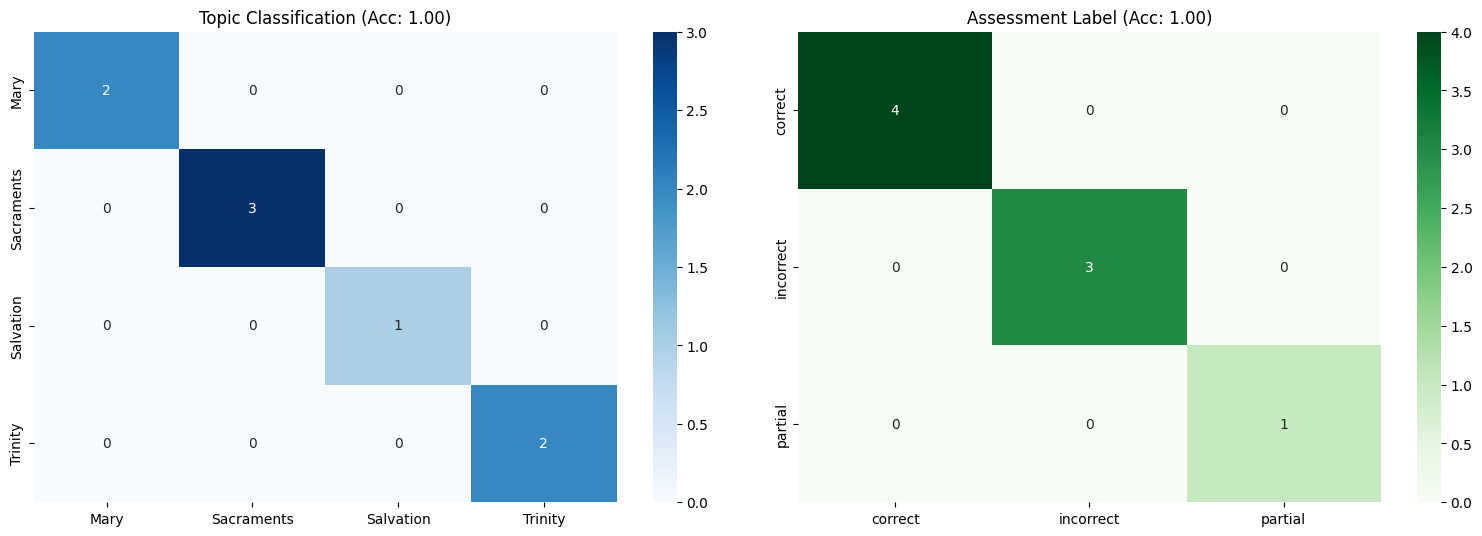

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import numpy as np
from nlp import NLPClassifier

# Re-creating the internal dataset for evaluation with full sentences
data = [
    ["Catholics worship Mary.", "Mary", "incorrect"],
    ["The Eucharist is symbolic.", "Sacraments", "incorrect"],
    ["God is Trinity.", "Trinity", "correct"],
    ["Faith alone saves.", "Salvation", "partial"],
    ["Confession forgives sins.", "Sacraments", "correct"],
    ["Mary is the Mother of God.", "Mary", "correct"],
    ["Baptism washes away original sin.", "Sacraments", "correct"],
    ["There are four persons in the Trinity.", "Trinity", "incorrect"]
]

df_eval = pd.DataFrame(data, columns=["text", "topic", "label"])

# Initialize Classifier
clf = NLPClassifier()

# Predictions
preds = [clf.classify(t) for t in df_eval['text']]
pred_topics = [p[0] for p in preds]
pred_labels = [p[1] for p in preds]

# Calculate Accuracy
topic_acc = accuracy_score(df_eval['topic'], pred_topics)
label_acc = accuracy_score(df_eval['label'], pred_labels)

# Plotting with increased width and layout adjustments to prevent overlap
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Topic Confusion Matrix
sns.heatmap(confusion_matrix(df_eval['topic'], pred_topics), annot=True, fmt='d',
            xticklabels=np.unique(pred_topics), yticklabels=np.unique(df_eval['topic']),
            ax=ax[0], cmap='Blues')
ax[0].set_title(f'Topic Classification (Acc: {topic_acc:.2f})')

# Label Confusion Matrix
sns.heatmap(confusion_matrix(df_eval['label'], pred_labels), annot=True, fmt='d',
            xticklabels=np.unique(pred_labels), yticklabels=np.unique(df_eval['label']),
            ax=ax[1], cmap='Greens')
ax[1].set_title(f'Assessment Label (Acc: {label_acc:.2f})')

plt.tight_layout(pad=3.0)
plt.show()

In [20]:
!pip install sentence-transformers faiss-cpu numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.3 MB/s eta 0:00:00


In [21]:
!pip install -q langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.3/513.3 kB 15.6 MB/s eta 0:00:00


In [22]:
%%writefile rag.py
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

class RAGSystem:
    def __init__(self, processed_data):
        self.docs = []
        self.refs = []

        # Initialize text splitter for better chunking
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=500,
            chunk_overlap=50,
            length_function=len,
        )

        all_chunks = []
        all_metadata = []

        for item in processed_data:
            text = item.get("text", "")
            ref = item.get("number", "N/A")

            # Split long paragraphs into smaller chunks
            chunks = text_splitter.split_text(text)
            for chunk in chunks:
                all_chunks.append(chunk)
                all_metadata.append(ref)

        self.docs = all_chunks
        self.refs = all_metadata

        # Use a high-quality model
        self.model = SentenceTransformer("all-mpnet-base-v2")
        embeddings = self.model.encode(self.docs, show_progress_bar=True)

        self.index = faiss.IndexFlatL2(embeddings.shape[1])
        self.index.add(np.array(embeddings).astype("float32"))

    def retrieve(self, query, k=3):
        query_vec = self.model.encode([query])
        distances, indices = self.index.search(np.array(query_vec).astype("float32"), k)

        results = []
        for i, idx in enumerate(indices[0]):
            results.append({
                "text": self.docs[idx],
                "ref": self.refs[idx],
                "score": float(distances[0][i])
            })
        return results

    def analyze(self, query, top_k=5):
        query_vec = self.model.encode([query])
        distances, indices = self.index.search(np.array(query_vec).astype("float32"), top_k)

        results = []
        for i, idx in enumerate(indices[0]):
            results.append({
                "rank": i + 1,
                "ref": self.refs[idx],
                "text": self.docs[idx],
                "score": float(distances[0][i])
            })
        return query_vec[0], results

Writing rag.py


# RAG Model Evaluation
Evaluating the accuracy of the `RAG` using a train-test split and visualization.

In [23]:
%%writefile rag.py
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

class RAGSystem:
    def __init__(self, processed_data):
        self.docs = []
        self.refs = []
        texts = []

        # Fix: Ensure we use the correct key 'number' from the processed data
        for item in processed_data:
          if isinstance(item, dict):
              text = item.get("text", "")
              # Use 'number' because that is what extract_ccc_paragraphs creates
              ref = item.get("number", "N/A")
          else:
              text = str(item)
              ref = "N/A"

          self.docs.append(text)
          self.refs.append(ref)
          texts.append(text)

        self.model = self.load_model()
        embeddings = self.model.encode(texts, show_progress_bar=False)
        self.index = faiss.IndexFlatL2(len(embeddings[0]))
        self.index.add(np.array(embeddings).astype("float32"))

    @staticmethod
    def load_model():
        return SentenceTransformer("all-MiniLM-L6-v2")

    def retrieve(self, query, k=3):
        query_vec = self.model.encode([query])
        D, I = self.index.search(np.array(query_vec).astype("float32"), k)

        results = []
        for idx in I[0]:
            results.append({
                "text": self.docs[idx],
                "ref": self.refs[idx]
            })
        return results

    def analyze(self, query, top_k=5):
        query_vec = self.model.encode([query])

        distances, indices = self.index.search(
            np.array(query_vec).astype("float32"), top_k
        )

        results = []
        for i, idx in enumerate(indices[0]):
            results.append({
                "rank": i + 1,
                "ref": self.refs[idx],
                "text": self.docs[idx],
                "score": float(distances[0][i])
            })

        return query_vec[0], results

Overwriting rag.py


In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings(rag, query, passages):
    texts = [p["text"] for p in passages]
    texts.append(query)

    embeddings = rag.model.encode(texts)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    plt.figure()
    for i, point in enumerate(reduced):
        if i == len(reduced) - 1:
            plt.scatter(point[0], point[1])
            plt.text(point[0], point[1], "QUERY")
        else:
            plt.scatter(point[0], point[1])
            plt.text(point[0], point[1], f"P{i}")

    st.pyplot(plt)

In [25]:
import streamlit as st
from rag import RAGSystem

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-04-16 20:54:30.453 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.515 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-16 20:54:30.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.754 Thread 'MainThread': mi

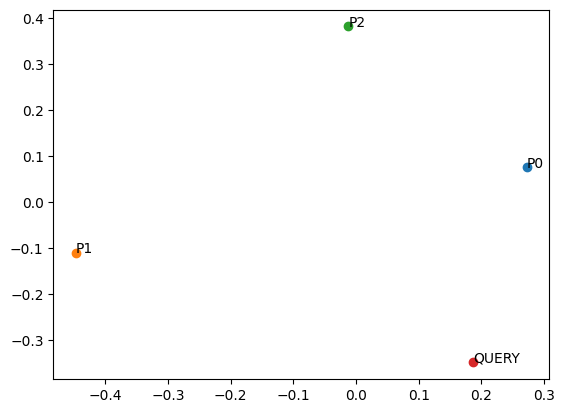

In [26]:
import streamlit as st
from rag import RAGSystem

# 1. Initialize the RAG system and sample data
# The variable 'rag' in the global scope was overwritten by 'import rag' in previous cells
# and refers to the module, not an instance. We need to explicitly re-initialize it.
rag = RAGSystem(ccc_data)

# 2. Define sample inputs for the plot if they don't exist
user_input = "What is the Trinity?"
passages = rag.retrieve(user_input, k=3)

# 3. Attempt to plot
try:
    st.subheader("📊 RAG Embedding Space")
    plot_embeddings(rag, user_input, passages)
except Exception as e:
    print(f"Streamlit UI warning (Expected in notebook): {e}")
    print("Plotting using matplotlib directly:")
    plot_embeddings(rag, user_input, passages)

In [27]:
import numpy as np

def plot_similarity(rag, query, passages):
    query_vec = rag.model.encode([query])[0]
    doc_vecs = rag.model.encode([p["text"] for p in passages])

    scores = np.dot(doc_vecs, query_vec)

    st.bar_chart(scores)

In [28]:
import streamlit as st
from rag import RAGSystem

st.subheader("📈 Relevance Scores")
plot_similarity(rag, user_input, passages)

2026-04-16 20:54:30.860 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:30.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:32.593 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:32.594 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 20:54:32.595 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [29]:
%%writefile plots.py
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import streamlit as st
import numpy as np
import pandas as pd

def plot_embeddings(rag_system, query, results):
    # results is a list of dicts, each with 'text'
    texts = [r["text"] for r in results]
    texts.append(query) # Add the query to the texts

    embeddings = rag_system.model.encode(texts)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and axes
    for i, point in enumerate(reduced):
        if i == len(reduced) - 1:
            ax.scatter(point[0], point[1], color='red', s=100, label='Query', zorder=5) # Larger and on top
            ax.text(point[0] + 0.05, point[1], "Query", color='red', weight='bold')
        else:
            ax.scatter(point[0], point[1], color='blue', s=70, label=f'Doc {i+1}')
            ax.text(point[0] + 0.05, point[1], f"Doc {i+1}")

    ax.set_title('Document Embeddings vs. Query in 2D PCA Space')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    st.pyplot(fig) # Pass the figure object to st.pyplot

def plot_similarity(rag_system, query, results):
    # results is a list of dicts, each with 'text' and 'score' (L2 distance)
    # Convert L2 distance to a similarity score for intuitive plotting
    # Lower L2 distance means higher similarity. Using 1 / (1 + distance).
    similarity_scores = [1 / (1 + r['score']) for r in results]
    doc_labels = [f"CCC {r['ref']}" for r in results] # Shorten labels for chart

    # Create a pandas Series for easy plotting with st.bar_chart
    score_series = pd.Series(similarity_scores, index=doc_labels)
    st.bar_chart(score_series)

Writing plots.py


In [30]:
# Testing the fix with user input and sentence validation
import importlib
import rag
import re
importlib.reload(rag)
from rag import RAGSystem

if 'ccc_data' in globals():
    rag_instance = RAGSystem(ccc_data)
    user_query = input("Enter your theological question: ")

    if user_query.strip():
        results = rag_instance.retrieve(user_query)

        print(f"\nResults for: {user_query}")
        print("-" * 30)
        for r in results:
            text = r['text'].strip()
            # Check if the retrieved text ends with sentence-terminal punctuation
            if re.search(r'[.!?]$', text):
                print(f"CCC {r['ref']}: {text}")
                print()
            else:
                # Skip fragments or partial headers
                continue
    else:
        print("Please enter a valid query.")
else:
    print("Error: 'ccc_data' not found.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Enter your theological question: The Trinitiy is not 3

Results for: The Trinitiy is not 3
------------------------------
CCC 49: The divine Unity is Triune.

CCC 120: since they manifest and communicate to men, above all in the Eucharist, the mystery of communion with the God who is love, One in three persons.



In [31]:
# 1. Reload the data using the UPDATED CLEAN extraction logic
ccc_data = load_ccc()

# 2. Re-initialize the RAG system with the updated data
import importlib
import rag
importlib.reload(rag)
from rag import RAGSystem

if len(ccc_data) > 0:
    rag_instance = RAGSystem(ccc_data)

    # 3. Test a query to verify that numbers are now clean
    test_query = "What is the Trinity?"
    results = rag_instance.retrieve(test_query, k=5)

    print(f"Verification for: {test_query}")
    for i, r in enumerate(results):
        print(f"{i+1}. [Reference: CCC {r['ref']}] {r['text'][:150]}...")
else:
    print("Error: No paragraphs were extracted.")

Loaded 7981 CCC paragraphs


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Verification for: What is the Trinity?
1. [Reference: CCC 49] The Trinity is a mystery of faith in the strict sense, one of the "mysteries that are hidden in God, which can never be known unless they are revealed...
2. [Reference: CCC 49] for there is only one God, the almighty Father, his only Son and the Holy Spirit: the Most Holy Trinity....
3. [Reference: CCC 49] The mystery of the Most Holy Trinity is the central mystery of the Christian faith and of Christian life. God alone can make it known to us by reveali...
4. [Reference: CCC 49] III. THE HOLY TRINITY IN THE TEACHING OF THE FAITH...
5. [Reference: CCC 49] reveals in its fullness the mystery of the Holy Trinity....


## Improving RAG Document Correlation

The effectiveness of the Retrieval Augmented Generation (RAG) model in finding relevant documents is heavily dependent on the quality of its **embedding model**. This model transforms text into numerical vectors (embeddings) where semantically similar texts are located closer to each other in a high-dimensional space.

To enhance how closely the retrieved documents correlate to your queries, we will upgrade the `SentenceTransformer` model used by the RAG system. The current `all-MiniLM-L6-v2` is a good general-purpose model, but more powerful models exist that can capture richer semantic nuances.

We will replace `all-MiniLM-L6-v2` with `**all-mpnet-base-v2**`. This model typically offers better performance in semantic similarity tasks, leading to more accurate and relevant document retrievals. Keep in mind that larger models like `all-mpnet-base-v2` may increase processing time and memory usage slightly, but the improvement in retrieval quality is often worth the trade-off.

In [32]:
%%writefile rag.py
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

class RAGSystem:
    def __init__(self, processed_data):
        self.docs = []
        self.refs = []
        texts = []

        # Fix: Ensure we use the correct key 'number' from the processed data
        for item in processed_data:
          if isinstance(item, dict):
              text = item.get("text", "")
              # Use 'number' because that is what extract_ccc_paragraphs creates
              ref = item.get("number", "N/A")
          else:
              text = str(item)
              ref = "N/A"

          self.docs.append(text)
          self.refs.append(ref)
          texts.append(text)

        self.model = self.load_model()
        embeddings = self.model.encode(texts, show_progress_bar=False)
        self.index = faiss.IndexFlatL2(len(embeddings[0]))
        self.index.add(np.array(embeddings).astype("float32"))

    @staticmethod
    def load_model():
        # Upgrading the embedding model for better semantic correlation
        return SentenceTransformer("all-mpnet-base-v2")

    def retrieve(self, query, k=3):
        query_vec = self.model.encode([query])
        D, I = self.index.search(np.array(query_vec).astype("float32"), k)

        results = []
        for idx in I[0]:
            results.append({
                "text": self.docs[idx],
                "ref": self.refs[idx]
            })
        return results

    def analyze(self, query, top_k=5):
        query_vec = self.model.encode([query])

        distances, indices = self.index.search(
            np.array(query_vec).astype("float32"), top_k
        )

        results = []
        for i, idx in enumerate(indices[0]):
            results.append({
                "rank": i + 1,
                "ref": self.refs[idx],
                "text": self.docs[idx],
                "score": float(distances[0][i])
            })

        return query_vec[0], results

Overwriting rag.py


Running The Program

In [33]:
from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()

In [34]:
from pyngrok import ngrok

ngrok.set_auth_token("3C64YPKuEMqjFCu8NY3Qt3c0Epw_52BGursoR2Z4UsvQ8Pgfs")

In [37]:
from pyngrok import ngrok
import threading
import os

def run():
    os.system("streamlit run app.py --server.port 8501")

threading.Thread(target=run).start()

public_url = ngrok.connect(8501, bind_tls=True)
print(public_url)

NgrokTunnel: "https://merrie-abient-camilla.ngrok-free.dev" -> "http://localhost:8501"
